In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.calibration import CalibratedClassifierCV
from scipy.stats import entropy

import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv(r"‪D:\ML Data\Spesis\anti_total.csv".strip('\u202a'), index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

temp_df = data_filter[all_site_cols].copy().astype(str).apply(lambda x: x.str.strip())
temp_df = temp_df.replace(['', 'nan', 'None', 'nan.0'], '0')

temp_df = temp_df.astype(float)

has_site_mask = (temp_df > 0).any(axis=1)

site_samples = data[has_site_mask].copy()

print(f"原始樣本數: {len(data)}")
print(f"至少標註一個部位的樣本數: {len(site_samples)}")
print(f"被排除掉的『全空/全0』樣本數: {len(data) - len(site_samples)}")


原始樣本數: 27968
至少標註一個部位的樣本數: 11880
被排除掉的『全空/全0』樣本數: 16088


In [9]:
len(site_samples), len(site_samples['ACCOUNTNO'])

(11880, 11880)

In [10]:
site_samples['Clindamycin'].sum(), site_samples['Gentamicin'].sum()

(np.float64(379.0), np.float64(201.0))

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
site_samples['ROOMNO'] = site_samples['ROOMNO'].map(roomno_mapping)          

site_samples['SEX'] = site_samples['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    site_samples[col] = site_samples[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(site_samples.columns) - set(abx_cols))
X = site_samples[feature_cols]
y = site_samples[final_cols]

In [13]:
X.shape, y.shape

((11880, 68), (11880, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir', 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X[has_label_mask]
y = y[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")

原本樣本數: 11880
過濾後樣本數: 11470
已刪除 410 筆因刪除藥物欄位而變成『無給藥』的樣本


In [16]:
X.columns

Index(['O2 SAT', 'BE(ecf)', 'FEVER', 'PH', 'StayTime_hours',
       'Microscopic RBC level', 'K', 'VITALSIGNSPR', 'Microscopic WBC level',
       'PLT', 'AUTOIMMUNE', 'GPT', 'Nitrite level', 'SEX', 'HCO3', 'MAP',
       'INFECTIONSITE3', 'INJURELEVEL', 'Leukocyte level', 'CHECKITEM31SCORE',
       'CHECKITEM27SCORE', 'Neutrophil Seg.', 'CHECKITEM29SCORE',
       'VITALSIGNSSPO2', 'INFECTIONSITE9', 'INR', 'CHECKITEM27', 'Na',
       'CANCER', 'CHECKITEM28SCORE', 'CRP', 'AGE', 'LIVER', 'INFECTIONSITE4',
       'CHECKITEM32SCORE', 'T.Bilirubin', 'PCO2', 'Ht', 'Lymphocyte', 'WBC',
       'VITALSIGNSBT', 'OTHERINFECTIONSITE_flag', 'PT', 'Bacteria level',
       'INFECTIONSITE5', 'CNS', 'INFECTIONSITE1', 'Absolute Neutrophil count',
       'Hb', 'APTT', 'CHECKITEM30SCORE', 'CHECKITEM28A', 'DM', 'HST',
       'VITALSIGNSRR', 'INFECTIONSITE2', 'KIDNEY', 'VITALSIGNSDBP',
       'RESPIRATORY', 'Creatinine', 'VITALSIGNSGCS', 'CARDIOVASCULAR'],
      dtype='object')

In [17]:
y[y.columns].sum().sort_values(ascending=False)

Flomoxef                       5190.0
Amoxicillin/Clavulanic acid    1581.0
Piperacillin/Tazobactam        1509.0
Cefoperazone/sulbactam         1411.0
Metronidazole                   916.0
Ciprofloxacin                   872.0
Cefixime                        851.0
Azithromycin                    695.0
Ceftriaxone                     609.0
Cefazolin                       589.0
Levofloxacin                    501.0
Cefuroxime                      497.0
Clindamycin                     379.0
Gentamicin                      201.0
Ampicillin                       88.0
dtype: float64

In [18]:
####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

X['Bacteria level_flag'] = (
     X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


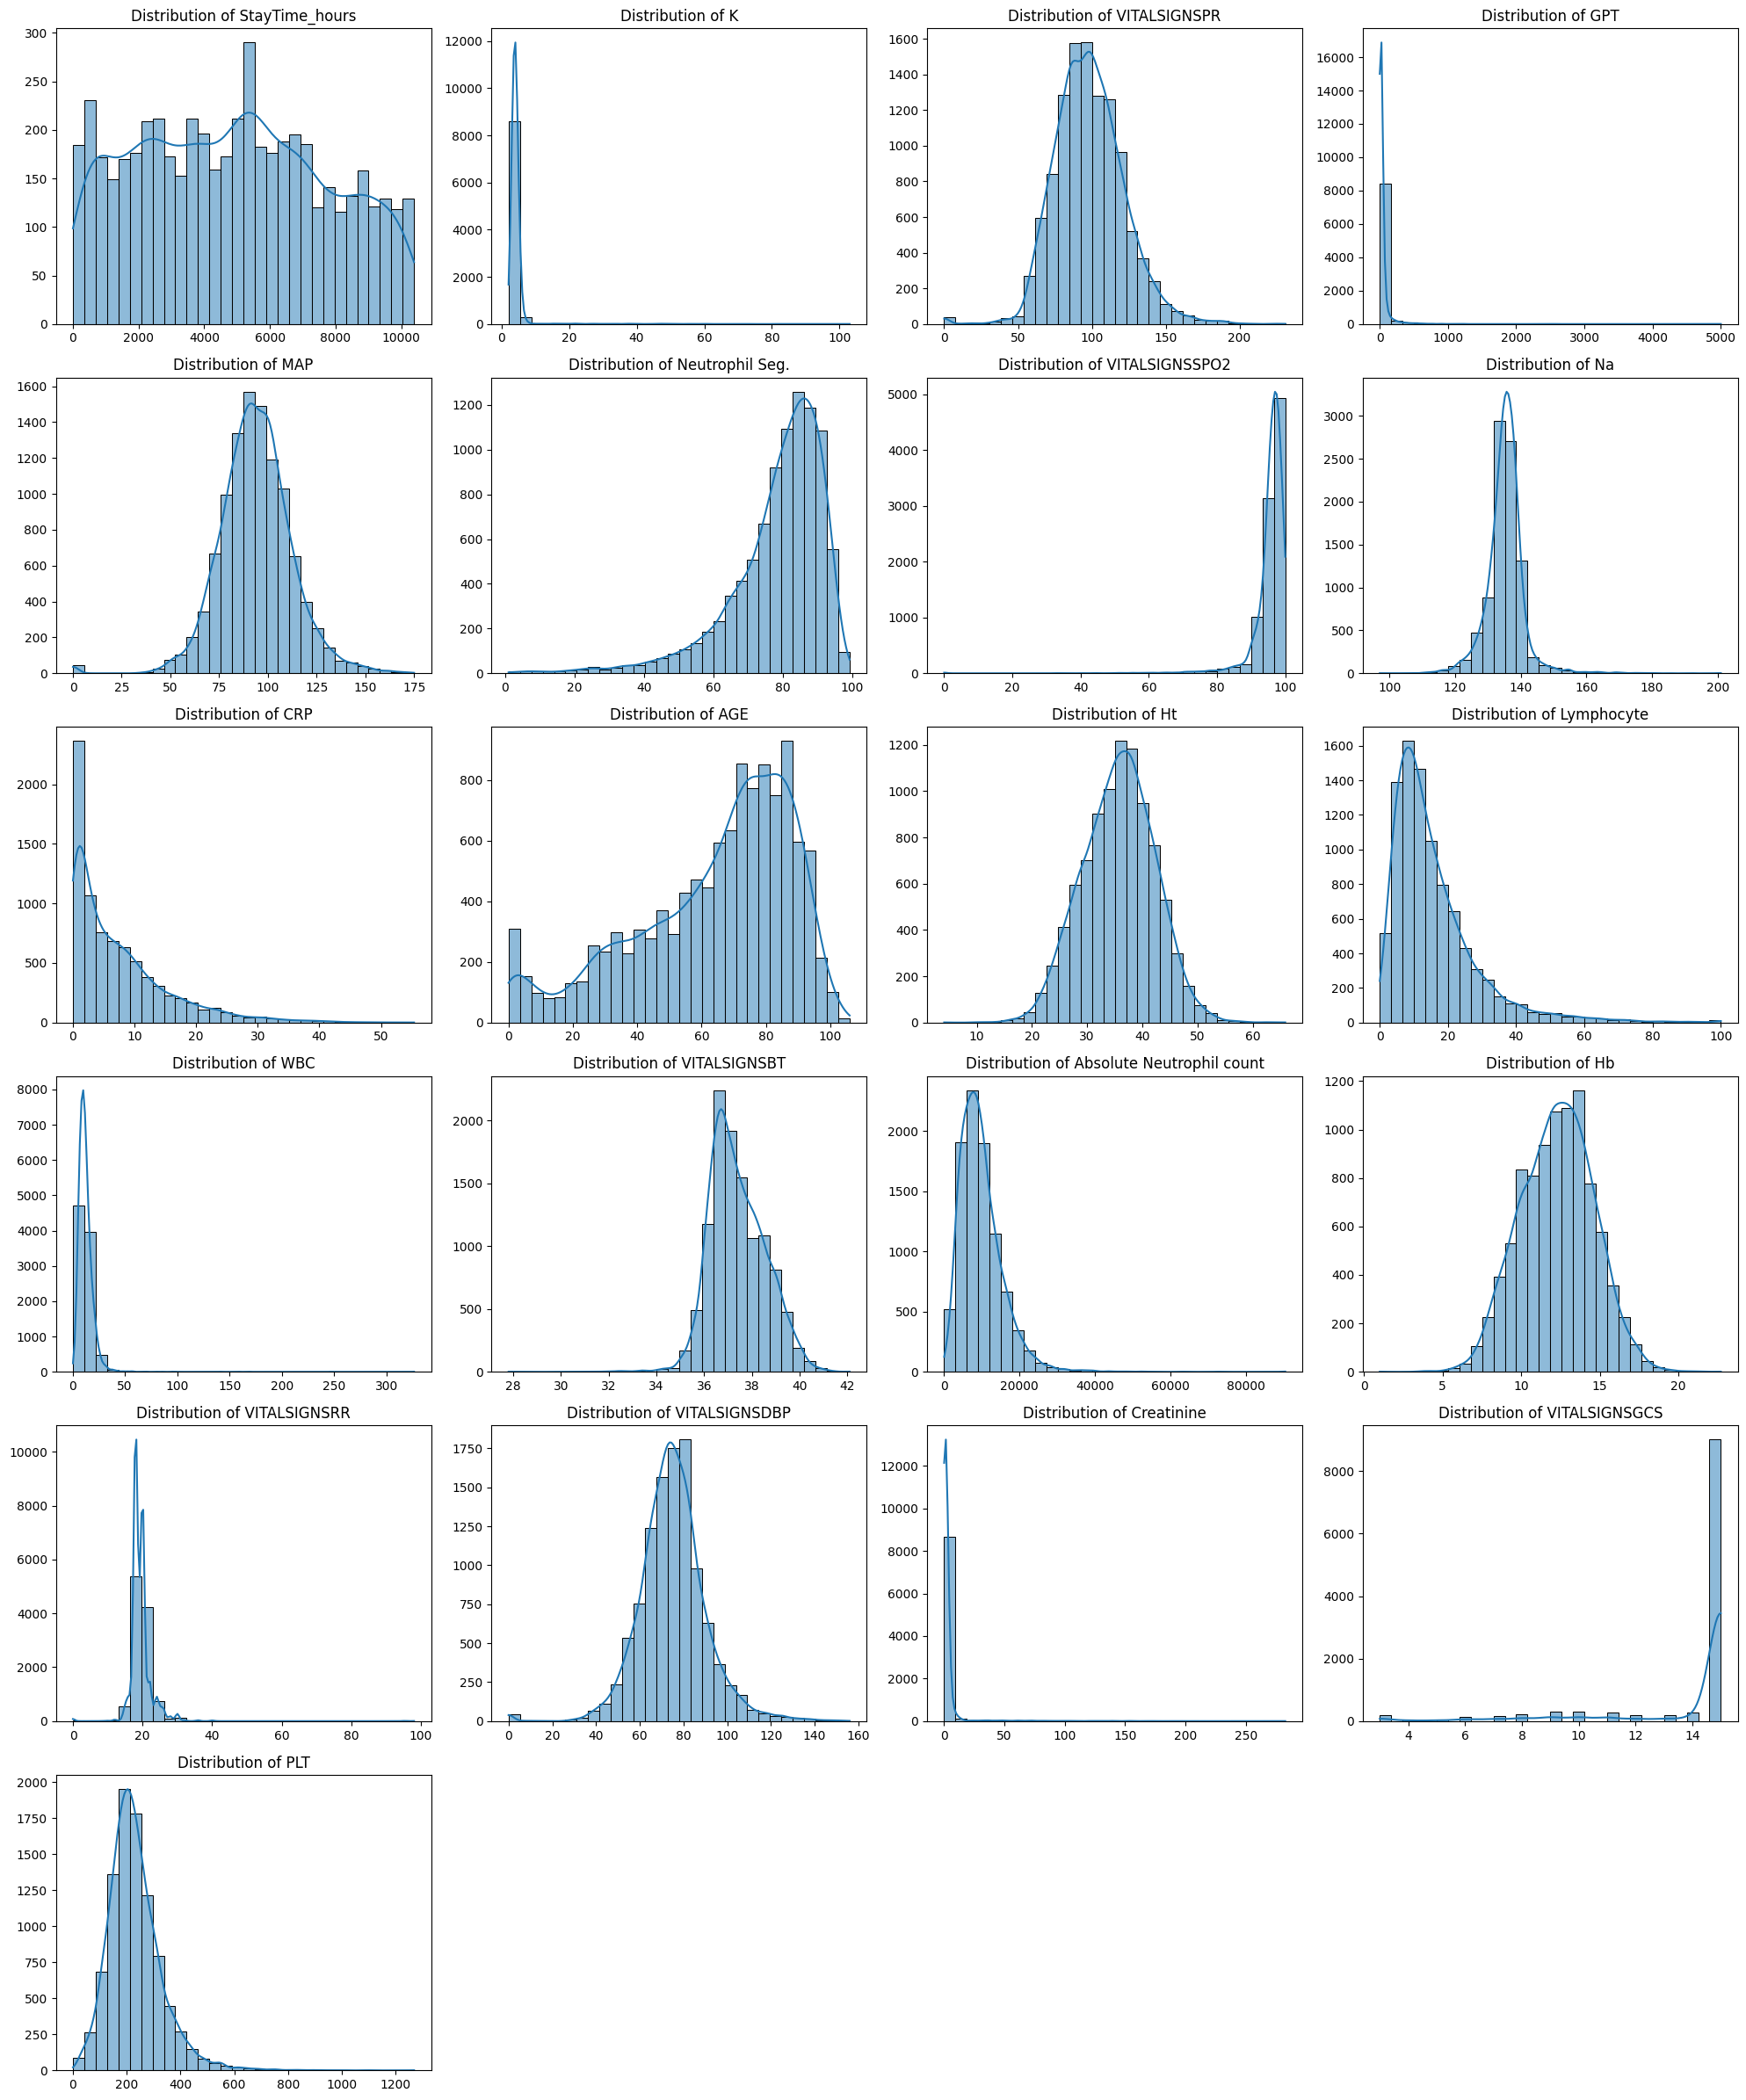

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [20]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 3916

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              105                   113   
MAP                                        99                   105   
VITALSIGNSDBP                             101                    98   
WBC                                        93                    93   
VITALSIGNSBT                               90                    96   
Absolute Neutrophil count                  92                    92   
PLT                                        92                    92   
Ht                                         93                    91   
Lymphocyte                                 84                    93   
Creatinine                                 85                    91   

                           Total_Outliers  
VITALSIGNSPR                          218  
MAP                                   204  
VITALSIGNSDBP                         199  
WBC  

In [21]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((9176, 85), (9176, 15), (2294, 85), (2294, 15))

In [23]:
X_train.isnull().sum(), X_test.isnull().sum()

(O2 SAT                   7020
 BE(ecf)                  7018
 FEVER                       0
 PH                       5148
 StayTime_hours           5035
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 85, dtype: int64,
 O2 SAT                   1753
 BE(ecf)                  1750
 FEVER                       0
 PH                       1306
 StayTime_hours           1273
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 85, dtype: int64)

In [24]:
X_train.dtypes, X_test.dtypes

(O2 SAT                   float64
 BE(ecf)                  float64
 FEVER                      int64
 PH                       float64
 StayTime_hours           float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 85, dtype: object,
 O2 SAT                   float64
 BE(ecf)                  float64
 FEVER                      int64
 PH                       float64
 StayTime_hours           float64
                           ...   
 CHECKITEM27_flag           int64
 CHECKITEM27SCORE_flag      int64
 CHECKITEM28SCORE_flag      int64
 CHECKITEM31SCORE_flag      int64
 CHECKITEM32SCORE_flag      int64
 Length: 85, dtype: object)

In [25]:
y_train.sum().sort_values(ascending=False)

Flomoxef                       4148.0
Amoxicillin/Clavulanic acid    1253.0
Piperacillin/Tazobactam        1199.0
Cefoperazone/sulbactam         1140.0
Metronidazole                   752.0
Ciprofloxacin                   702.0
Cefixime                        695.0
Azithromycin                    544.0
Ceftriaxone                     489.0
Cefazolin                       466.0
Cefuroxime                      399.0
Levofloxacin                    394.0
Clindamycin                     300.0
Gentamicin                      171.0
Ampicillin                       78.0
dtype: float64

In [26]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [27]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [28]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [29]:
# fill score

score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
              'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
              'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
              'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
              'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [30]:
y_train.sum(axis=1).mean() # 每人平均用1.24個抗生素

np.float64(1.3873147340889276)

In [31]:
drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
             'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
             'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
             'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [32]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [33]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(9176, 62)

In [34]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [35]:
X_train.columns

Index(['FEVER', 'StayTime_hours', 'K', 'VITALSIGNSPR', 'PLT', 'AUTOIMMUNE',
       'GPT', 'SEX', 'MAP', 'INFECTIONSITE3', 'INJURELEVEL', 'Neutrophil Seg.',
       'VITALSIGNSSPO2', 'INFECTIONSITE9', 'Na', 'CANCER', 'CRP', 'AGE',
       'LIVER', 'INFECTIONSITE4', 'Ht', 'Lymphocyte', 'WBC', 'VITALSIGNSBT',
       'OTHERINFECTIONSITE_flag', 'INFECTIONSITE5', 'CNS', 'INFECTIONSITE1',
       'Absolute Neutrophil count', 'Hb', 'DM', 'VITALSIGNSRR',
       'INFECTIONSITE2', 'KIDNEY', 'VITALSIGNSDBP', 'RESPIRATORY',
       'Creatinine', 'VITALSIGNSGCS', 'CARDIOVASCULAR', 'Leukocyte level_flag',
       'Nitrite level_flag', 'Bacteria level_flag',
       'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
       'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', 'HST_flag',
       'T.Bilirubin_flag', 'PT_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag',
       'HCO3_flag', 'BE(ecf)_flag', 'O2 SAT_flag', 'CHECKITEM28A_flag',
       'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKI

In [36]:
# LogisticRegressionCV?
# XGBClassifier?
# RandomForestClassifier?
# MultiOutputClassifier.fit?

In [37]:
calibrated_models = []

for i, col in enumerate(y_train.columns): # or for i in range(y_train.shape[1])
    base_model = XGBClassifier(n_estimators=300,
                               max_depth=5,
                               learning_rate=0.05,
                               subsample=0.8,
                               colsample_bytree=0.8,
                               eval_metric='logloss',
                               gamma=0,
                               reg_alpha=2.0,
                               reg_lambda=0.0,
                               min_child_weight=1,
                               scale_pos_weight=2,
                               random_state =123,
                               n_jobs=-1 )
    
    calibrated = CalibratedClassifierCV(
        base_model,
        method='isotonic',  # or 'sigmoid'、'isotonic'
        cv=3
    )

    calibrated.fit(X_train, y_train.iloc[:, i])
    calibrated_models.append(calibrated)

In [38]:
# # # 原始機率
y_prob_list = np.column_stack([model.predict_proba(X_test)[:, 1] for model in calibrated_models])

# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# 計算每種抗生素權重(F1/recall)
f1_per_label = []

for i in range(y_train.shape[1]):
    y_train_pred = calibrated_models[i].predict(X_train)
    f1 = f1_score(y_train.iloc[:, i], y_train_pred)
    f1_per_label.append(f1)

drug_weight = 1 / (np.array(f1_per_label) + 1e-3)

#  normalize
drug_weight = drug_weight / drug_weight.mean()

alpha = 0.01 # penalty
belta = 0.9

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = (np.log(y_prob_list + 1e-8)+ beta * np.log(drug_weight)- alpha * np.log(drug_freq))
adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)

# 用adjusted_scores排序(Top-K核心)
k=3
topk_idx = np.argsort(adjusted_scores, axis=1)[:, -k:]

# 建立 prediction matrix（for metric）
y_pred_matrix = np.zeros_like(y_prob_list)

for i in range(len(y_prob_list)):
    y_pred_matrix[i, topk_idx[i]] = 1

In [39]:
drug_weight

array([0.2001692 , 0.17213741, 0.31218101, 0.25826109, 5.82928193,
       4.0532832 , 0.28285416, 1.62635564, 0.40092596, 0.32803997,
       0.21001961, 0.18954542, 0.48571988, 0.35232692, 0.2988986 ])

In [40]:
drug_weight ** belta

array([0.23510265, 0.20525216, 0.35072428, 0.2957012 , 4.8871262 ,
       3.52392173, 0.32092704, 1.54915178, 0.43929652, 0.36671957,
       0.24549004, 0.2238422 , 0.5220923 , 0.39106707, 0.33726517])

In [41]:
print(f1_score(y_test, y_pred_matrix, average='micro'))
print(f1_score(y_test, y_pred_matrix, average='macro'))

0.3625136938551937
0.3808328819257733


In [42]:
jaccard_score(y_test, y_pred_matrix, average='samples', zero_division=0)

np.float64(0.2461929671607091)

In [44]:
hamming_loss(y_test, y_pred_matrix)

0.1860215053763441

In [45]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

hit3 = hit_rate_at_k(y_test.values, adjusted_scores, k=5)
print('Hit@3: ', hit3)
precision3 = precision_at_k(y_test.values, adjusted_scores, k=5)
print('precision@3: ', precision3)
recall_3 = recall_at_k(y_test.values, adjusted_scores, k=5)
print('Recall@3: ', recall_3)
map_3 = map_at_k(y_test.values, adjusted_scores, k=5)
print('MAP@3: ', map_3)

Hit@3:  0.8936355710549259
precision@3:  0.2241499564080139
Recall@3:  0.8304272013949433
MAP@3:  0.423848445219413


In [46]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, adjusted_scores, y_test.values, drug_names, k=5)

實際給藥: ['Cefoperazone/sulbactam']

推薦藥物:
1. Cefixime (Score: 0.8658)
2. Cefoperazone/sulbactam (Score: 0.7694)
3. Flomoxef (Score: 0.1782)
4. Azithromycin (Score: 0.0809)
5. Metronidazole (Score: 0.0641)
實際給藥: ['Levofloxacin']

推薦藥物:
1. Cefixime (Score: 0.1693)
2. Cefuroxime (Score: 0.1578)
3. Cefoperazone/sulbactam (Score: 0.1489)
4. Cefazolin (Score: 0.1045)
5. Ciprofloxacin (Score: 0.1013)
實際給藥: ['Piperacillin/Tazobactam']

推薦藥物:
1. Cefoperazone/sulbactam (Score: 0.7949)
2. Piperacillin/Tazobactam (Score: 0.1536)
3. Cefixime (Score: 0.1010)
4. Levofloxacin (Score: 0.0999)
5. Azithromycin (Score: 0.0946)
實際給藥: ['Levofloxacin']

推薦藥物:
1. Cefoperazone/sulbactam (Score: 0.8730)
2. Cefixime (Score: 0.3281)
3. Flomoxef (Score: 0.1179)
4. Levofloxacin (Score: 0.1131)
5. Azithromycin (Score: 0.0838)
實際給藥: ['Piperacillin/Tazobactam']

推薦藥物:
1. Cefoperazone/sulbactam (Score: 0.6739)
2. Piperacillin/Tazobactam (Score: 0.1438)
3. Azithromycin (Score: 0.0946)
4. Levofloxacin (Score: 0.0814)
5. Ce

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# 挑選你想診斷的藥物
target_drug = 'Levofloxacin' #  , 'Cephalexin', 'Cefadroxil'

# 計算 MI
# discrete_features: 如果你的特徵有類別型（如部位），要標註 True
mi_scores = mutual_info_classif(X_train, y_train[target_drug], discrete_features='auto', random_state=123)

# 整理成 DataFrame
mi_df = pd.DataFrame({'feature': X_train.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values(by='mi_score', ascending=False)

print(f"=== {target_drug} 的特徵資訊量排行 ===")
print(mi_df.head(10))